## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
fatal: unable to access 'https://github.com/Lv1g1/RecSys-Challenge-2025.git/': Could not resolve host: github.com


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os
import pandas as pd
from xgboost import XGBRanker
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_holdout_split, XGBOOST_DATAFRAMES
from Challenge.utils import evaluate_recommender
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
_, URM_outer = load_holdout_split()

In [5]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_OOF.parquet")

X_train = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,Label,EASE_R_Score,EASE_R_RankPosition,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,13,0,0,0,0,0,0,0.146634,106,...,2.763314,646,539,59,0.084832,0.081167,0.221003,77,413,1541.376587
1,0,5706,0,0,0,1,1,0,0.180238,58,...,2.756729,827,1427,10,0.191343,0.202138,0.577017,72,485,1429.055542
2,0,5766,0,0,1,1,1,0,0.305060,16,...,2.756729,351,1050,16,0.273811,0.139576,0.503647,72,2895,1429.055542
3,0,5830,0,0,0,0,0,0,0.162575,75,...,2.777495,412,1056,20,0.230950,0.167745,0.525276,72,1731,1429.055542
4,0,5956,0,0,0,0,0,0,0.241022,31,...,2.803360,43,47,10,0.289829,0.098583,0.472416,72,1454,1429.055542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23176689,27094,640,0,0,0,1,1,0,0.275289,76,...,4.523964,84,51,17,0.359248,0.152304,0.757386,221,2377,874.778259
23176690,27094,797,0,0,0,0,0,0,0.247680,96,...,4.458327,214,356,19,0.349893,0.228300,0.704917,221,615,874.778259
23176691,27094,868,0,0,0,0,0,0,0.316601,55,...,4.585932,706,1181,48,0.239673,0.137379,0.441403,221,6416,874.778259
23176692,27094,101,0,0,0,0,0,0,0.396964,33,...,4.503058,67,64,7,0.413890,0.196016,0.665027,221,576,818.176453


In [7]:
if not X_train['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train = X_train.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='snappy',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [8]:
assert X_train['UserID'].is_monotonic_increasing, "UserID column is not sorted in increasing order!"

# Group Calculation
groups = X_train.groupby("UserID").size().values

# Target and Feature Matrix Definition
y_train = X_train["Label"]

# Drop the identifiers (UserID, ItemID) and the target (Label), keeping only the features
X_train = X_train.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_train[col] = X_train[col].astype('category')

assert groups.sum() == X_train.shape[0], "Group sum does not match total data size!"

## **Train Baseline**

In [9]:
# Hyperparameters (Your baseline configuration)
n_estimators = 50
learning_rate = 1e-1
reg_alpha = 1e-1
reg_lambda = 1e-1
max_depth = 5
grow_policy = "depthwise"
objective = "pairwise" 

XGB_model = XGBRanker(objective='rank:{}'.format(objective),
                      n_estimators = int(n_estimators),
                      random_state = 42, # Fixed seed for reproducibility
                      learning_rate = learning_rate,
                      reg_alpha = reg_alpha,
                      reg_lambda = reg_lambda,
                      max_depth = int(max_depth),
                      max_leaves = 0,
                      grow_policy = grow_policy,
                      verbosity = 1, # Set to 1 to see training progress
                      booster = "gbtree",
                      n_jobs=-1, # Use all cores

                      enable_categorical=True,
                      callbacks=[ProgressCallback(n_estimators)]
                      )

In [10]:
print(f"Starting XGBRanker training with {len(groups)} user groups...")

XGB_model.fit(X_train,
              y_train,
              group=groups
              )

Starting XGBRanker training with 27095 user groups...
[Training] Tree 50/50

,objective,'rank:pairwise'
,base_score,None
,booster,'gbtree'
,callbacks,[<Challenge.XG...x7f2a338801a0>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## **Score**

In [11]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(X_train)
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7145


In [12]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_OOF.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_val[col] = X_val[col].astype('category')

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,86,0,0,0,0,0,0.158978,80,0.457685,...,2.869778,381,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524
1,0,227,0,0,1,1,1,0.230409,33,0.449216,...,2.907956,691,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524
2,0,275,0,0,0,0,0,0.061567,283,0.457007,...,2.855224,81,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524
3,0,282,0,0,0,1,1,0.182080,58,0.356088,...,2.841163,100,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524
4,0,291,0,0,0,0,0,0.119798,132,0.373464,...,2.869778,324,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,27094,6328,0,0,0,1,1,0.115149,263,0.577463,...,4.539614,78,72,11,0.379431,0.228762,0.806681,250,213,933.643982
2296114,27094,6516,0,1,1,1,1,0.448237,16,0.432170,...,4.409982,463,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982
2296115,27094,6620,0,0,0,0,0,0.311993,56,0.289841,...,4.494019,313,248,56,0.237791,0.118687,0.424300,250,396,933.643982
2296116,27094,6724,0,0,0,0,1,0.147140,199,0.557740,...,4.494019,204,240,17,0.315344,0.215339,0.724451,250,225,933.643982


In [19]:
# Reorder val columns to match training set
feature_cols = [c for c in X_train.columns if c != 'Label'] + ['UserID', 'ItemID']
X_val = X_val[feature_cols]

In [20]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostRerankerRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Eval Batches: 100%|██████████| 28/28 [00:02<00:00, 12.49it/s]

Validation Score (RECALL@20): 0.2925


## **Plots**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

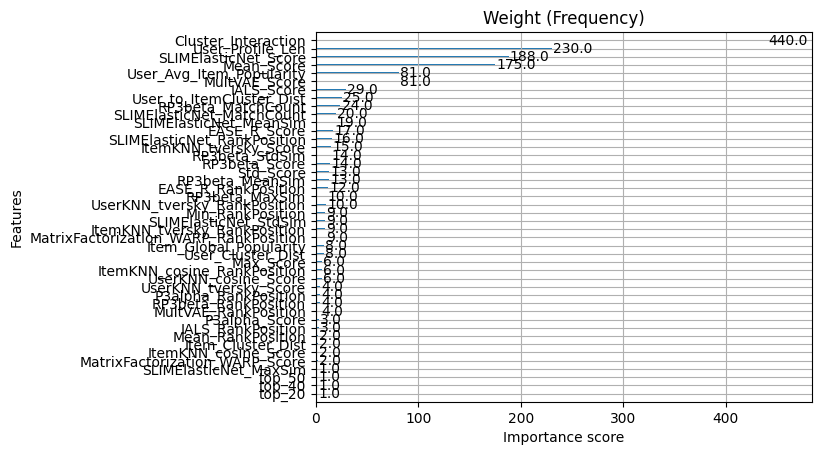

In [21]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

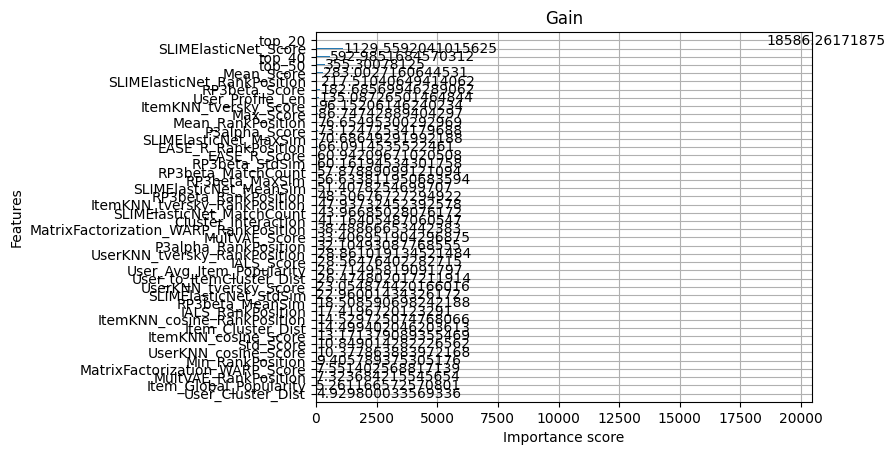

In [22]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

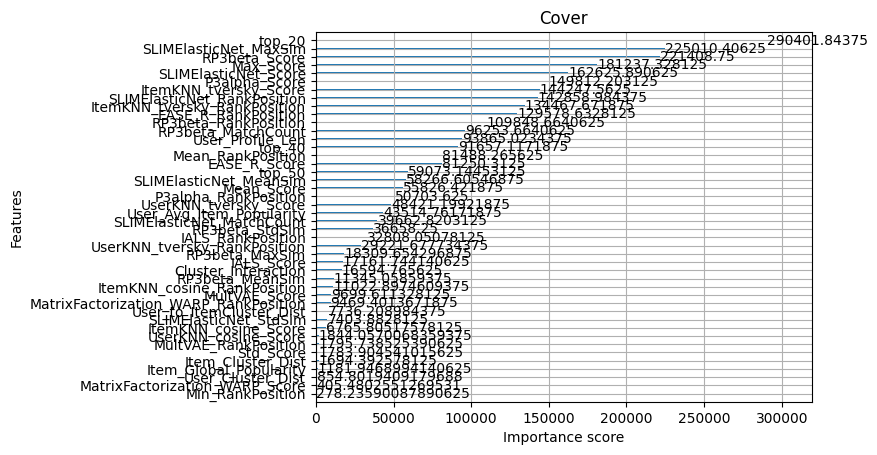

In [23]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

## **Second Trial**

In [26]:
# Updated Hyperparameters
n_estimators = 500       # INCREASE: 50 is far too low for ranking. Try 200, 500, or 1000.
learning_rate = 0.05     # DECREASE: Lower this when increasing estimators to converge smoothly.
max_depth = 6            # INCREASE: Capture deeper interactions (try 6 to 8).
reg_alpha = 0.5          # INCREASE: L1 regularization to prune unnecessary features.
reg_lambda = 0.5         # INCREASE: L2 regularization.

# KEY CHANGE: Randomness to break "top_20" dominance
colsample_bytree = 0.7   # Only look at 70% of features per tree. 
                         # This FORCES the model to use features other than 'top_20'.
subsample = 0.8          # Only use 80% of rows per tree.

XGB_model = XGBRanker(
    objective='rank:ndcg',
    n_estimators=n_estimators,
    learning_rate=learning_rate,
    max_depth=max_depth,
    reg_alpha=reg_alpha,
    reg_lambda=reg_lambda,
    colsample_bytree=colsample_bytree,
    subsample=subsample,
    tree_method="hist",      # Faster training
    n_jobs=-1,
    random_state=42,

    enable_categorical=True,
    callbacks=[ProgressCallback(n_estimators)]
)

In [27]:
XGB_model.fit(X_train,
              y_train,
              group=groups
              )

[Training] Tree 500/500

,objective,'rank:ndcg'
,base_score,None
,booster,None
,callbacks,[<Challenge.XG...x7f28981d1590>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [28]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(X_train)
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7171


In [29]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostRerankerRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Eval Batches: 100%|██████████| 28/28 [00:06<00:00,  4.63it/s]

Validation Score (RECALL@20): 0.2942


<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

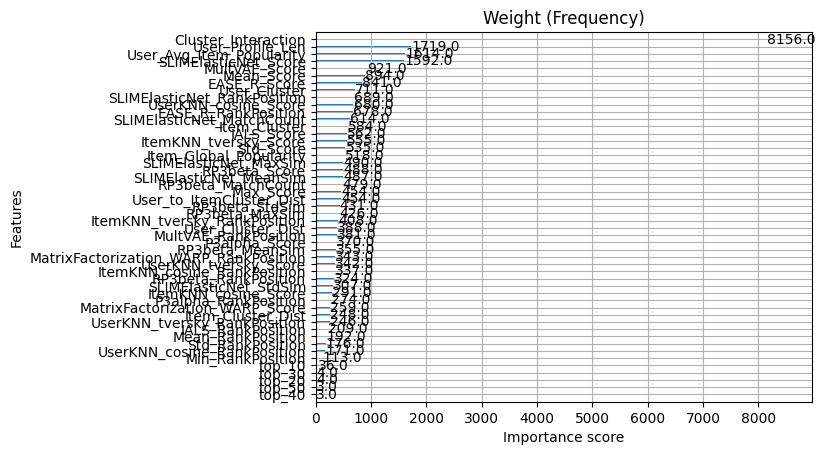

In [30]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

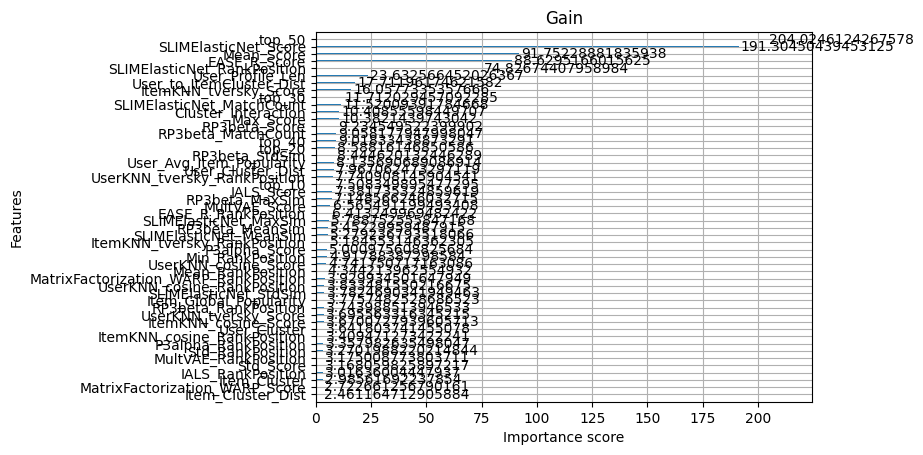

In [31]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

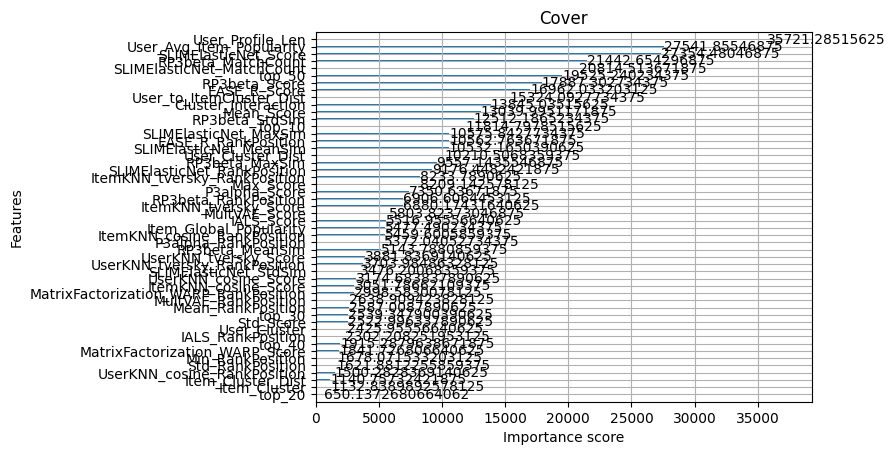

In [32]:
plot_importance(XGB_model, importance_type='cover', title='Cover')